# Space–time finite elements for elastic wave propagation

This example solves the impact of a one-dimensional elastic bar against a rigid wall using a **space–time finite element formulation**.

The main idea is simple: instead of discretizing space first and then advancing the solution with a time-stepping algorithm, **time is treated as an additional finite-element coordinate**. The complete evolution of the bar is obtained from a single finite-element solve over the space–time domain.

The example considers only the interval during which the bar remains in contact with the rigid wall. During this phase, no contact algorithm is required: the velocity of the impacted end is simply constrained to zero.

The result illustrates the complete impact process:

1. a compressive wave starts at the rigid wall,
2. it propagates through the bar with the elastic wave speed,
3. it reflects from the free end as a release wave,
4. and when the reflected wave returns to the wall, the bar is ready to separate and rebound.

All of this is obtained **without a time-stepping loop**.

In [1]:
using LowLevelFEM

## Governing equations

For a homogeneous elastic bar, the longitudinal wave speed is

$$
c=\sqrt{\frac{E}{\rho}},
$$

where $E$ is Young's modulus and $\rho$ is the mass density.

Instead of displacement, it is convenient to use the particle velocity $v$ and the axial stress $\sigma$. The one-dimensional elastodynamic equations can then be written as the first-order system

$$
\rho\,v_{,t}-\sigma_{,x}=0,
$$

$$
\sigma_{,t}-E\,v_{,x}=0.
$$

We introduce the scaled time coordinate

$$
y=ct
$$

and the normalized stress

$$
s=\frac{\sigma}{\rho c}.
$$

Using $E=\rho c^2$, the equations reduce to the symmetric dimensionless form

$$
\boxed{
v_{,y}-s_{,x}=0,
\qquad
s_{,y}-v_{,x}=0.
}
$$

The two finite-element coordinates are therefore $x$ and $y=ct$. Since they have the same physical dimension, elastic waves propagate along the $45^\circ$ characteristic lines

$$
x\pm y=\text{constant}.
$$


In [2]:
mat = Material("body", E=2e5, ν=0.3)

E = mat.E
ρ = mat.ρ

c = √(E / ρ)
L = 1
A = 4
v_0 = 1

t_contact = 2L / c
σ_contact = -ρ * c * v_0
F_contact = A * σ_contact

println("Duration of contact: ", t_contact, "s")
println("Contact stress: ", σ_contact, "MPa")
println("Contact force: ", F_contact, "N")

Duration of contact: 3.96232255123179e-7s
Contact stress: -0.0396232255123179MPa
Contact force: -0.1584929020492716N


## The space–time domain

The bar occupies

$$
0\le x\le L.
$$

Only the contact phase of the impact is considered. A compression wave needs a time $L/c$ to travel from the rigid wall to the free end, and the reflected release wave needs another $L/c$ to return.

Therefore,

$$
0\le t\le \frac{2L}{c},
$$

or, using the scaled coordinate $y=ct$,

$$
\boxed{
0\le x\le L,
\qquad
0\le y\le 2L.
}
$$

The entire impact event can thus be represented by an ordinary two-dimensional finite-element mesh in the $(x,y)$ plane.

Two scalar fields are introduced:

- $v(x,y)$: particle velocity,
- $s(x,y)=\sigma/(\rho c)$: normalized axial stress.

Standard continuous Lagrange finite elements are used for both fields.


In [3]:
structured_rect_mesh(lx=L, ly=2L, n=100, order=1)

renumberNodes!(mat, method=:RCMK)

V = Field([mat], type=:ScalarField, dim=2, field=:v)
S = Field([mat], type=:ScalarField, dim=2, field=:s);

## Least-squares space–time formulation

Define the residuals of the first-order equations as

$$
r_1=v_{,y}-s_{,x},
\qquad
r_2=s_{,y}-v_{,x}.
$$

A straightforward Bubnov–Galerkin treatment of the first-order hyperbolic system does not lead to the same coercive variational structure as a standard elliptic problem. A **least-squares formulation** avoids this difficulty and leads to a symmetric formulation that can be discretized directly with standard continuous Lagrange finite elements.

The exact solution makes both residuals zero, so minimizing their squared $L^2$-norm over the complete space–time domain $Q$ provides a natural finite-element approximation.

$$
J(v,s)
=
\frac12
\int_Q
\left[
r_1^2+r_2^2
\right]\,dQ.
$$

Taking the variation of $J$, with test functions $w$ and $q$, gives

$$
\int_Q
(w_{,y}-q_{,x})(v_{,y}-s_{,x})
+
(q_{,y}-w_{,x})(s_{,y}-v_{,x})
\,dQ
=0.
$$

After expansion, the four blocks of the coupled system are

$$
K_{vv}
=
\int_Q
\left(
w_{,x}v_{,x}
+
w_{,y}v_{,y}
\right)dQ,
$$

$$
K_{vs}
=
-\int_Q
\left(
w_{,x}s_{,y}
+
w_{,y}s_{,x}
\right)dQ,
$$

$$
K_{sv}
=
-\int_Q
\left(
q_{,x}v_{,y}
+
q_{,y}v_{,x}
\right)dQ,
$$

$$
K_{ss}
=
\int_Q
\left(
q_{,x}s_{,x}
+
q_{,y}s_{,y}
\right)dQ.
$$

Introducing

$$
I=
\begin{bmatrix}
1&0\\
0&1
\end{bmatrix},
\qquad
C=
\begin{bmatrix}
0&-1\\
-1&0
\end{bmatrix},
$$

these expressions translate almost directly into the LowLevelFEM weak-form syntax.

In [4]:
I = [1.0 0.0
    0.0 1.0]

C = [0.0 -1.0
    -1.0 0.0]

Kvv = ∫(Grad(V) ⋅ I ⋅ Grad(V))
Kvs = ∫(Grad(V) ⋅ C ⋅ Grad(S))

Ksv = ∫(Grad(S) ⋅ C ⋅ Grad(V))
Kss = ∫(Grad(S) ⋅ I ⋅ Grad(S));

## Coupled finite-element system

The four bilinear forms are assembled into the $2\times2$ block system

$$
\begin{bmatrix}
K_{vv} & K_{vs}\\
K_{sv} & K_{ss}
\end{bmatrix}
\begin{bmatrix}
v\\
s
\end{bmatrix}
=
\begin{bmatrix}
0\\
0
\end{bmatrix}.
$$

In LowLevelFEM, the coupled multifield matrix is constructed directly from the four field-level matrices:

In [5]:
K = SystemMatrix([
    Kvv Kvs
    Ksv Kss]);

## Initial and boundary conditions: impact against a rigid wall

Initially, the complete bar moves toward the wall with velocity $v_0$ and is stress free:

$$
v(x,0)=v_0,
\qquad
s(x,0)=0.
$$

The rigid wall is located at $x=L$. During contact, the impacted end cannot move,

$$
v(L,y)=0.
$$

At the opposite end, the bar is traction free,

$$
\sigma(0,y)=0,
$$

or equivalently,

$$
s(0,y)=0.
$$

At the corner $(x,y)=(L,0)$, the wall condition requires $v=0$, while the rest of the bar still has its initial velocity $v_0$. This discontinuity is precisely what launches the compression wave into the bar.

Thus the complete set of conditions is

$$
\boxed{
\begin{aligned}
v(x,0)&=v_0,\\
s(x,0)&=0,\\
v(L,y)&=0,\\
s(0,y)&=0.
\end{aligned}}
$$

Only the interval $0\le y\le2L$ is solved. At $y=2L$, the release wave returns to the wall and contact ends. Extending the imposed condition $v(L,y)=0$ beyond this instant would artificially keep the bar attached to the wall.

In [6]:
v0 = ScalarField(V, "bottom", (x, y, z)->x == L ? 0 : v_0);

In [7]:
bc_v1 = BoundaryCondition("bottom", problem=V, v=v0)
bc_s1 = BoundaryCondition("bottom", problem=S, s=0.0)
bc_v2 = BoundaryCondition("right", problem=V, v=0.0)
bc_s2 = BoundaryCondition("left", problem=S, s=0.0);

## No external forcing is required

The impact is driven entirely by the initial and boundary conditions. There is no distributed forcing inside the space–time domain, so both right-hand sides are zero.

In [8]:
f_v = ∫(V ⋅ 0.0)
f_s = ∫(S ⋅ 0.0)

f = SystemVector([f_v, f_s]);

## One solve for the complete impact event

The complete space–time solution is now obtained from a **single coupled finite-element solve**.

There is no time loop, no time-step size, and no Newmark, HHT, central-difference or other time-integration algorithm. Time has already been discretized as part of the two-dimensional finite-element domain.

In [9]:
v, s = solveField(K, f, support=[bc_v1, bc_v2, bc_s1, bc_s2]);

## Interpretation of the solution

The result reproduces the classical one-dimensional elastic impact solution.

### Compression phase

Immediately after impact, a compression wave travels from the rigid wall toward the free end. Ahead of the wave,

$$
v=v_0,
\qquad
s=0,
$$

while behind it,

$$
v=0,
\qquad
s=-v_0.
$$

Therefore the compressive stress behind the wave is constant:

$$
\boxed{
\sigma=-\rho c v_0
}
$$

and the corresponding contact force is

$$
\boxed{
F=-A\rho c v_0.
}
$$

The first wave reaches the free end at

$$
t=\frac{L}{c}.
$$

At this instant the complete bar is compressed and momentarily at rest.

### Release and rebound

At the traction-free end the compression wave reflects as a release wave. Behind the reflected wave,

$$
v=-v_0,
\qquad
s=0.
$$

The bar therefore recovers its original length while acquiring the opposite velocity.

When the release wave returns to the rigid wall,

$$
\boxed{
t=\frac{2L}{c},
}
$$

the contact pressure becomes zero and the bar separates from the wall with velocity $-v_0$.

The two straight fronts visible in the space–time plots are the characteristic lines of the wave equation.

Away from the wave fronts, the analytical solution is piecewise constant. The finite width of the fronts in the numerical solution is caused by representing the discontinuities with continuous finite-element shape functions.

In [10]:
showDoFResults(v, name="v(x, y=ct)", visible=true)
showDoFResults(s, name="s(x, y=ct)");

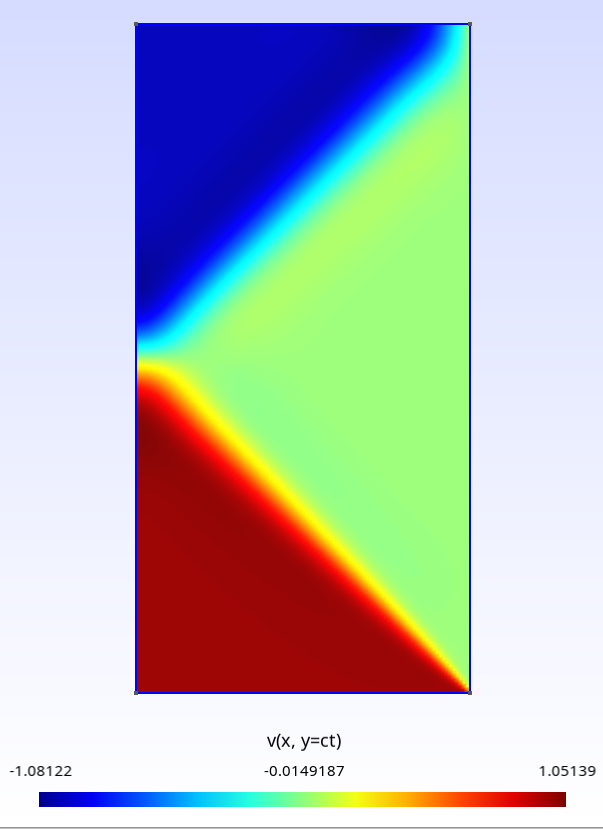 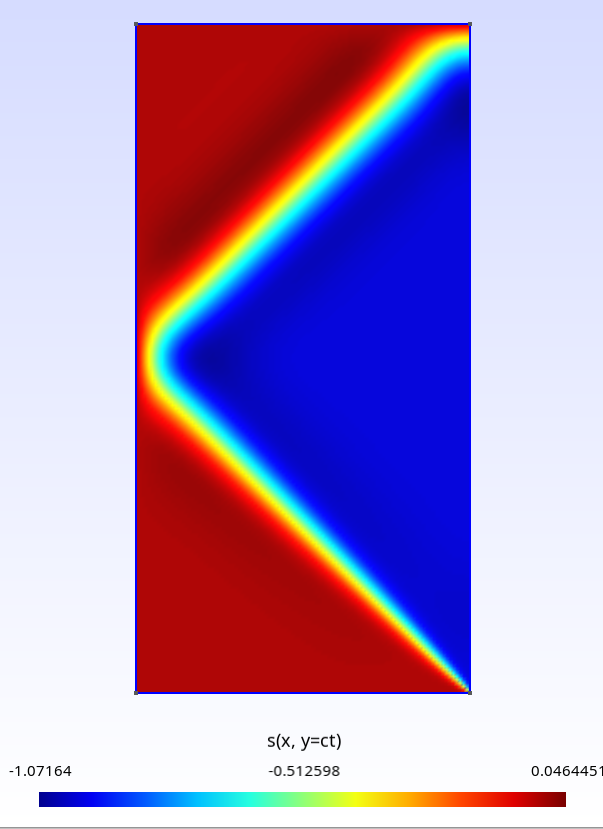

## What is unusual about this formulation?

In a conventional transient finite-element analysis, the spatial problem is discretized first and the resulting system of ordinary differential equations is advanced through time step by step.

Here, space and time are discretized together.

The complete sequence

$$
\text{impact}
\rightarrow
\text{compression wave}
\rightarrow
\text{reflection}
\rightarrow
\text{release}
\rightarrow
\text{rebound}
$$

is contained in one finite-element solution over the space–time domain.

For this example, the implementation requires only:

- two scalar fields,
- four bilinear forms,
- one $2\times2$ block matrix,
- four initial/boundary conditions,
- and one linear solve.

The mathematical weak form and its executable LowLevelFEM representation remain almost identical.

**No dedicated transient solver is used.** The entire dynamics follows from the weak form, the space–time mesh, and one linear solve.

In [11]:
openPostProcessor();

XOpenIM() failed
Fontconfig warning: using without calling FcInit()
